# Nike Financial Performance & Profitability Analysis

## Objective

This project analyses Nike's financial performance using financial statement data retrieved programmatically from the SEC EDGAR API.

The analysis focuses on:

- Revenue growth
- Profitability and margin development
- Operating performance
- Cash flow generation
- Financial position
- Key financial ratios
- Historical trends and profitability drivers
- Scenario-based financial forecasting

### Main Question

**How has Nike's financial performance evolved over recent years, what have been the main drivers of changes in profitability, and what does this indicate about the company's financial position?**

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt


## 1. Data Retrieval and Profitability Analysis

Financial statement data are retrieved programmatically from the SEC EDGAR Company Facts API using Nike's CIK. Annual 10-K observations are filtered to fiscal-year data, duplicate reporting dates are resolved by retaining the latest filed value, and monetary values are converted to USD billions.

The analysis begins by evaluating Nike's revenue, gross profit, SG&A expenses, EBIT and net income, together with their respective growth rates and profitability margins.

In [2]:
CIK = '0000320187'

headers = {
    "User-Agent": "Eleftherios Evangelou lefterisevaggelou@gmail.com" 
}

url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{CIK}.json"
response = requests.get(url, headers=headers)
response.raise_for_status()

nike_data=response.json()
gaap_facts = nike_data["facts"]["us-gaap"]

print(f"Company: {nike_data['entityName']}")
print(f"Available US-GAAP concepts: {len(gaap_facts)}")

Company: NIKE, Inc.
Available US-GAAP concepts: 443


In [4]:
def get_annual_metric(concept, column_name, start_year=2020, end_year=2026):
    data = pd.DataFrame(
        gaap_facts[concept]["units"]["USD"]
    )

    annual = data[
        (data["form"] == "10-K") &
        (data["fp"] == "FY")
    ].copy()

    annual["end"] = pd.to_datetime(annual["end"])

    annual = (
        annual
        .sort_values("filed")
        .drop_duplicates(subset="end", keep="last")
        .sort_values("end")
    )

    annual["Fiscal Year"] = annual["end"].dt.year

    annual = annual[
        annual["Fiscal Year"].between(start_year, end_year)
    ][["Fiscal Year", "val"]].copy()

    annual[column_name] = annual["val"] / 1e9

    return annual[
        ["Fiscal Year", column_name]
    ].reset_index(drop=True)

In [5]:
revenue_clean = get_annual_metric(
    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "Revenue ($bn)"
)

gross_profit_clean = get_annual_metric(
    "GrossProfit",
    "Gross Profit ($bn)"
)

display(revenue_clean)
display(gross_profit_clean)

,Fiscal Year,Revenue ($bn)
0,2020,37.403
1,2021,44.538
2,2022,46.710
3,2023,51.217
4,2024,51.362
5,2025,46.309
6,2026,46.398


,Fiscal Year,Gross Profit ($bn)
0,2020,16.241
1,2021,19.962
2,2022,21.479
3,2023,22.292
4,2024,22.887
5,2025,19.790
6,2026,19.911


In [6]:
net_income_clean = get_annual_metric(
    "NetIncomeLoss",
    "Net Income ($bn)"
)

sga_clean = get_annual_metric(
    "SellingGeneralAndAdministrativeExpense",
    "SG&A Expense ($bn)"
)

pretax_clean = get_annual_metric(
    "IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest",
    "Pre-Tax Income ($bn)"
)

interest_clean = get_annual_metric(
    "InterestIncomeExpenseNonoperatingNet",
    "Net Interest ($bn)"
)

In [7]:
financials = (
    revenue_clean
    .merge(gross_profit_clean, on="Fiscal Year")
    .merge(sga_clean, on="Fiscal Year")
    .merge(pretax_clean, on="Fiscal Year")
    .merge(net_income_clean, on="Fiscal Year")
    .merge(interest_clean, on="Fiscal Year")
)

In [8]:
financials["Gross Margin (%)"] = (
    financials["Gross Profit ($bn)"]
    / financials["Revenue ($bn)"]
    * 100
).round(2)

financials["SG&A (% Revenue)"] = (
    financials["SG&A Expense ($bn)"]
    / financials["Revenue ($bn)"]
    * 100
).round(2)

financials["EBIT ($bn)"] = (
    financials["Pre-Tax Income ($bn)"]
    - financials["Net Interest ($bn)"]
).round(3)

financials["EBIT Margin (%)"] = (
    financials["EBIT ($bn)"]
    / financials["Revenue ($bn)"]
    * 100
).round(2)

financials["Net Margin (%)"] = (
    financials["Net Income ($bn)"]
    / financials["Revenue ($bn)"]
    * 100
).round(2)

financials = financials[[
    "Fiscal Year",
    "Revenue ($bn)",
    "Gross Profit ($bn)",
    "Gross Margin (%)",
    "SG&A Expense ($bn)",
    "SG&A (% Revenue)",
    "EBIT ($bn)",
    "EBIT Margin (%)",
    "Pre-Tax Income ($bn)",
    "Net Income ($bn)",
    "Net Margin (%)",
    "Net Interest ($bn)"
]]

financials

,Fiscal Year,Revenue ($bn),Gross Profit ($bn),Gross Margin (%),SG&A Expense ($bn),SG&A (% Revenue),EBIT ($bn),EBIT Margin (%),Pre-Tax Income ($bn),Net Income ($bn),Net Margin (%),Net Interest ($bn)
0,2020,37.403,16.241,43.42,13.126,35.09,2.976,7.96,2.887,2.539,6.79,-0.089
1,2021,44.538,19.962,44.82,13.025,29.24,6.923,15.54,6.661,5.727,12.86,-0.262
2,2022,46.710,21.479,45.98,14.804,31.69,6.856,14.68,6.651,6.046,12.94,-0.205
3,2023,51.217,22.292,43.52,16.377,31.98,6.195,12.10,6.201,5.070,9.90,0.006
4,2024,51.362,22.887,44.56,16.576,32.27,6.539,12.73,6.700,5.700,11.10,0.161
5,2025,46.309,19.790,42.73,16.088,34.74,3.778,8.16,3.885,3.219,6.95,0.107
6,2026,46.398,19.911,42.91,16.114,34.73,3.850,8.30,3.900,3.108,6.70,0.050


In [9]:
financials["Revenue Growth (%)"] = (
    financials["Revenue ($bn)"]
    .pct_change()
    .mul(100)
    .round(2)
)

financials["Gross Profit Growth (%)"] = (
    financials["Gross Profit ($bn)"]
    .pct_change()
    .mul(100)
    .round(2)
)

financials["EBIT Growth (%)"] = (
    financials["EBIT ($bn)"]
    .pct_change()
    .mul(100)
    .round(2)
)

financials["Net Income Growth (%)"] = (
    financials["Net Income ($bn)"]
    .pct_change()
    .mul(100)
    .round(2)
)

financials[[
    "Fiscal Year",
    "Revenue Growth (%)",
    "Gross Profit Growth (%)",
    "EBIT Growth (%)",
    "Net Income Growth (%)"
]]

,Fiscal Year,Revenue Growth (%),Gross Profit Growth (%),EBIT Growth (%),Net Income Growth (%)
0,2020,NaN,NaN,NaN,NaN
1,2021,19.08,22.91,132.63,125.56
2,2022,4.88,7.60,-0.97,5.57
3,2023,9.65,3.79,-9.64,-16.14
4,2024,0.28,2.67,5.55,12.43
5,2025,-9.84,-13.53,-42.22,-43.53
6,2026,0.19,0.61,1.91,-3.45


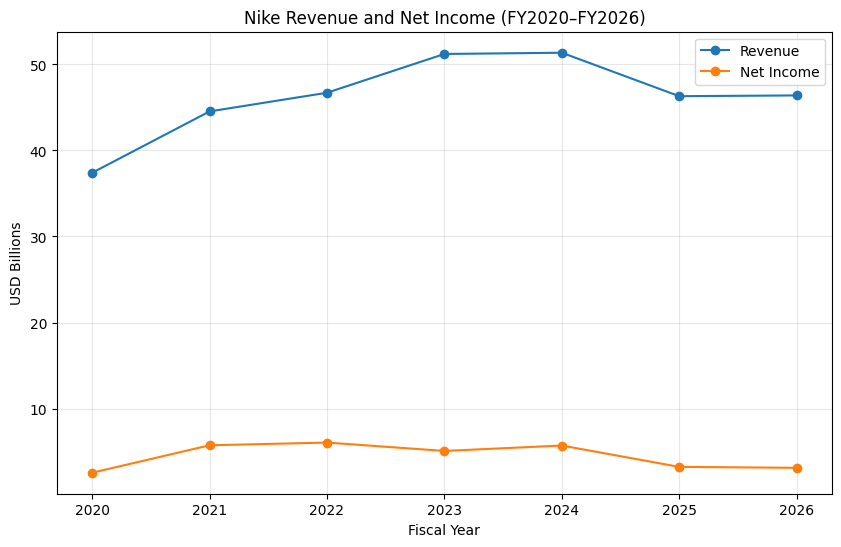

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["Fiscal Year"],
    financials["Revenue ($bn)"],
    marker="o",
    label="Revenue"
)

plt.plot(
    financials["Fiscal Year"],
    financials["Net Income ($bn)"],
    marker="o",
    label="Net Income"
)

plt.title("Nike Revenue and Net Income (FY2020–FY2026)")
plt.xlabel("Fiscal Year")
plt.ylabel("USD Billions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

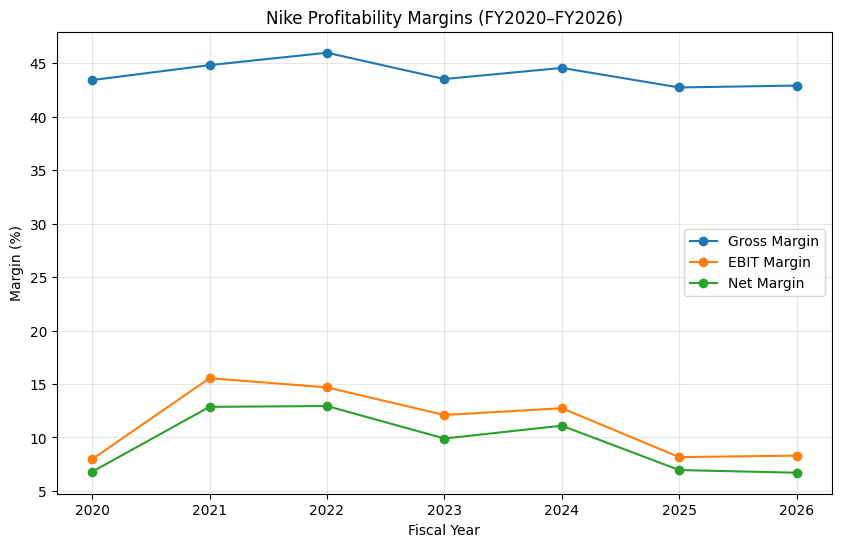

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["Fiscal Year"],
    financials["Gross Margin (%)"],
    marker="o",
    label="Gross Margin"
)

plt.plot(
    financials["Fiscal Year"],
    financials["EBIT Margin (%)"],
    marker="o",
    label="EBIT Margin"
)

plt.plot(
    financials["Fiscal Year"],
    financials["Net Margin (%)"],
    marker="o",
    label="Net Margin"
)

plt.title("Nike Profitability Margins (FY2020–FY2026)")
plt.xlabel("Fiscal Year")
plt.ylabel("Margin (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

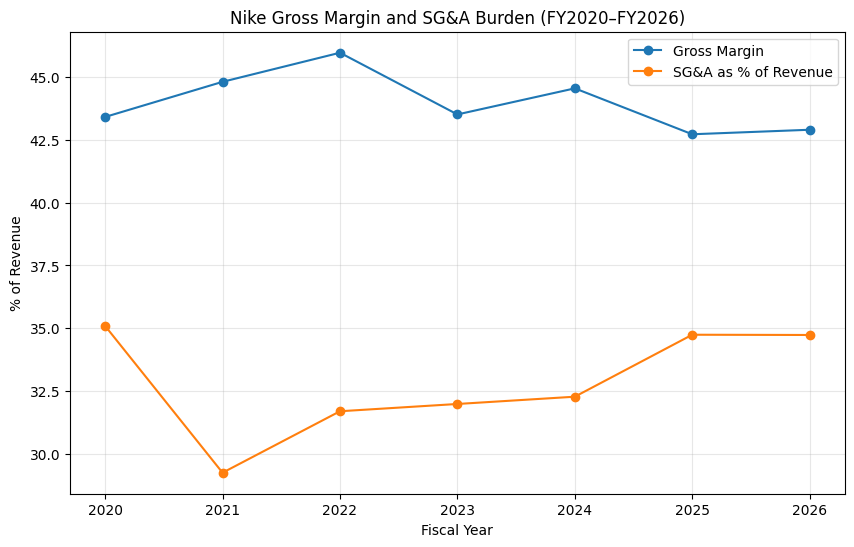

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["Fiscal Year"],
    financials["Gross Margin (%)"],
    marker="o",
    label="Gross Margin"
)

plt.plot(
    financials["Fiscal Year"],
    financials["SG&A (% Revenue)"],
    marker="o",
    label="SG&A as % of Revenue"
)

plt.title("Nike Gross Margin and SG&A Burden (FY2020–FY2026)")
plt.xlabel("Fiscal Year")
plt.ylabel("% of Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 2. Cash Flow Analysis

This section evaluates Nike's ability to convert earnings into cash and generate free cash flow. Operating cash flow and capital expenditures are used to calculate free cash flow, while selected working-capital movements are analysed to better understand changes in cash conversion.

In [13]:
operating_cash_flow_clean =  get_annual_metric(
    "NetCashProvidedByUsedInOperatingActivities",
    "Operating Cash Flow ($bn)"
)

capex_clean = get_annual_metric(
    "PaymentsToAcquirePropertyPlantAndEquipment",
    "CapEx ($bn)"
)

print("Operating Cash Flow")
display(operating_cash_flow_clean)

print("Capital Expenditure")
display(capex_clean)

Operating Cash Flow


,Fiscal Year,Operating Cash Flow ($bn)
0,2020,2.485
1,2021,6.657
2,2022,5.188
3,2023,5.841
4,2024,7.429
5,2025,3.698
6,2026,2.868


Capital Expenditure


,Fiscal Year,CapEx ($bn)
0,2020,1.086
1,2021,0.695
2,2022,0.758
3,2023,0.969
4,2024,0.812
5,2025,0.430
6,2026,0.684


In [14]:
financials = financials.merge(
    operating_cash_flow_clean,
    on="Fiscal Year",
    how="inner"
)

financials =  financials.merge(
    capex_clean,
    on="Fiscal Year",
    how="inner"
)

financials["Free Cash Flow ($bn)"] = (
    financials["Operating Cash Flow ($bn)"]
    - financials["CapEx ($bn)"]
).round(3)

financials[[
    "Fiscal Year",
    "Operating Cash Flow ($bn)",
    "CapEx ($bn)",
    "Free Cash Flow ($bn)"
]]

,Fiscal Year,Operating Cash Flow ($bn),CapEx ($bn),Free Cash Flow ($bn)
0,2020,2.485,1.086,1.399
1,2021,6.657,0.695,5.962
2,2022,5.188,0.758,4.430
3,2023,5.841,0.969,4.872
4,2024,7.429,0.812,6.617
5,2025,3.698,0.430,3.268
6,2026,2.868,0.684,2.184


In [15]:
financials["OCF / Net Income"] = (
    financials["Operating Cash Flow ($bn)"]
    / financials["Net Income ($bn)"]
).round(2)

financials["FCF Margin (%)"] = (
    financials["Free Cash Flow ($bn)"]
    / financials["Revenue ($bn)"]
    *100
).round(2)

financials[[
    "Fiscal Year",
    "Net Income ($bn)",
    "Operating Cash Flow ($bn)",
    "OCF / Net Income",
    "Free Cash Flow ($bn)",
    "FCF Margin (%)"
]]


,Fiscal Year,Net Income ($bn),Operating Cash Flow ($bn),OCF / Net Income,Free Cash Flow ($bn),FCF Margin (%)
0,2020,2.539,2.485,0.98,1.399,3.74
1,2021,5.727,6.657,1.16,5.962,13.39
2,2022,6.046,5.188,0.86,4.430,9.48
3,2023,5.070,5.841,1.15,4.872,9.51
4,2024,5.700,7.429,1.30,6.617,12.88
5,2025,3.219,3.698,1.15,3.268,7.06
6,2026,3.108,2.868,0.92,2.184,4.71


In [16]:
receivables_change_clean = get_annual_metric(
    "IncreaseDecreaseInAccountsReceivable",
    "Receivables Cash Flow Impact ($bn)"
)

inventory_change_clean = get_annual_metric(
    "IncreaseDecreaseInInventories",
    "Inventory Cash Flow Impact ($bn)"
)

payables_change_clean = get_annual_metric(
    "IncreaseDecreaseInAccountsPayableAndOtherOperatingLiabilities",
    "Payables & Operating Liabilities Cash Flow Impact ($bn)"
)

print("Accounts Receivable")
display(receivables_change_clean)

print("Inventory")
display(inventory_change_clean)

print("Accounts Payable & Other Operating Liabilities")
display(payables_change_clean)


Accounts Receivable


,Fiscal Year,Receivables Cash Flow Impact ($bn)
0,2020,-1.239
1,2021,1.606
2,2022,0.504
3,2023,-0.489
4,2024,0.329
5,2025,0.257
6,2026,1.207


Inventory


,Fiscal Year,Inventory Cash Flow Impact ($bn)
0,2020,1.854
1,2021,-0.507
2,2022,1.676
3,2023,0.133
4,2024,-0.908
5,2025,-0.120
6,2026,0.031


Accounts Payable & Other Operating Liabilities


,Fiscal Year,Payables & Operating Liabilities Cash Flow Impact ($bn)
0,2020,0.024
1,2021,1.326
2,2022,1.365
3,2023,-0.225
4,2024,0.397
5,2025,-0.426
6,2026,-0.959


In [17]:
working_capital = (
    receivables_change_clean
    .merge(inventory_change_clean, on="Fiscal Year")
    .merge(payables_change_clean, on="Fiscal Year")
)
working_capital

,Fiscal Year,Receivables Cash Flow Impact ($bn),Inventory Cash Flow Impact ($bn),Payables & Operating Liabilities Cash Flow Impact ($bn)
0,2020,-1.239,1.854,0.024
1,2021,1.606,-0.507,1.326
2,2022,0.504,1.676,1.365
3,2023,-0.489,0.133,-0.225
4,2024,0.329,-0.908,0.397
5,2025,0.257,-0.120,-0.426
6,2026,1.207,0.031,-0.959


In [18]:
working_capital["Receivables Cash Flow Impact ($bn)"] = (
    -receivables_change_clean["Receivables Cash Flow Impact ($bn)"]
)

working_capital["Inventory Cash Flow Impact ($bn)"] = (
    -inventory_change_clean["Inventory Cash Flow Impact ($bn)"]
)

working_capital

,Fiscal Year,Receivables Cash Flow Impact ($bn),Inventory Cash Flow Impact ($bn),Payables & Operating Liabilities Cash Flow Impact ($bn)
0,2020,1.239,-1.854,0.024
1,2021,-1.606,0.507,1.326
2,2022,-0.504,-1.676,1.365
3,2023,0.489,-0.133,-0.225
4,2024,-0.329,0.908,0.397
5,2025,-0.257,0.120,-0.426
6,2026,-1.207,-0.031,-0.959


In [19]:
other_assets_change_clean = get_annual_metric(
    "IncreaseDecreaseInPrepaidDeferredExpenseAndOtherAssets",
    "Prepaid & Other Assets Cash Flow Impact ($bn)"
)

other_assets_change_clean

,Fiscal Year,Prepaid & Other Assets Cash Flow Impact ($bn)
0,2020,0.654
1,2021,0.182
2,2022,0.845
3,2023,0.644
4,2024,0.260
5,2025,0.224
6,2026,-0.519


In [20]:
other_assets_change_clean["Prepaid & Other Assets Cash Flow Impact ($bn)"] = (
    - get_annual_metric(
        "IncreaseDecreaseInPrepaidDeferredExpenseAndOtherAssets",
        "Prepaid & Other Assets Cash Flow Impact ($bn)"
    )["Prepaid & Other Assets Cash Flow Impact ($bn)"]
)


working_capital = working_capital.merge(
    other_assets_change_clean,
    on="Fiscal Year",
    how="inner"
)

working_capital

,Fiscal Year,Receivables Cash Flow Impact ($bn),Inventory Cash Flow Impact ($bn),Payables & Operating Liabilities Cash Flow Impact ($bn),Prepaid & Other Assets Cash Flow Impact ($bn)
0,2020,1.239,-1.854,0.024,-0.654
1,2021,-1.606,0.507,1.326,-0.182
2,2022,-0.504,-1.676,1.365,-0.845
3,2023,0.489,-0.133,-0.225,-0.644
4,2024,-0.329,0.908,0.397,-0.260
5,2025,-0.257,0.120,-0.426,-0.224
6,2026,-1.207,-0.031,-0.959,0.519


In [21]:
working_capital["Selected Working Capital Impact ($bn)"] = (
    working_capital["Receivables Cash Flow Impact ($bn)"]
    + working_capital["Inventory Cash Flow Impact ($bn)"]
    + working_capital["Payables & Operating Liabilities Cash Flow Impact ($bn)"]
    + working_capital["Prepaid & Other Assets Cash Flow Impact ($bn)"]
).round(3)

working_capital

,Fiscal Year,Receivables Cash Flow Impact ($bn),Inventory Cash Flow Impact ($bn),Payables & Operating Liabilities Cash Flow Impact ($bn),Prepaid & Other Assets Cash Flow Impact ($bn),Selected Working Capital Impact ($bn)
0,2020,1.239,-1.854,0.024,-0.654,-1.245
1,2021,-1.606,0.507,1.326,-0.182,0.045
2,2022,-0.504,-1.676,1.365,-0.845,-1.660
3,2023,0.489,-0.133,-0.225,-0.644,-0.513
4,2024,-0.329,0.908,0.397,-0.260,0.716
5,2025,-0.257,0.120,-0.426,-0.224,-0.787
6,2026,-1.207,-0.031,-0.959,0.519,-1.678


In [22]:
financials = financials.merge(
    working_capital[[
        "Fiscal Year",
        "Selected Working Capital Impact ($bn)"
    ]],
    on="Fiscal Year",
    how="inner"
)


In [23]:
financials[[
    "Fiscal Year",
    "Net Income ($bn)",
    "Operating Cash Flow ($bn)",
    "Selected Working Capital Impact ($bn)",
    "Free Cash Flow ($bn)",
    "FCF Margin (%)"
]]

,Fiscal Year,Net Income ($bn),Operating Cash Flow ($bn),Selected Working Capital Impact ($bn),Free Cash Flow ($bn),FCF Margin (%)
0,2020,2.539,2.485,-1.245,1.399,3.74
1,2021,5.727,6.657,0.045,5.962,13.39
2,2022,6.046,5.188,-1.660,4.430,9.48
3,2023,5.070,5.841,-0.513,4.872,9.51
4,2024,5.700,7.429,0.716,6.617,12.88
5,2025,3.219,3.698,-0.787,3.268,7.06
6,2026,3.108,2.868,-1.678,2.184,4.71


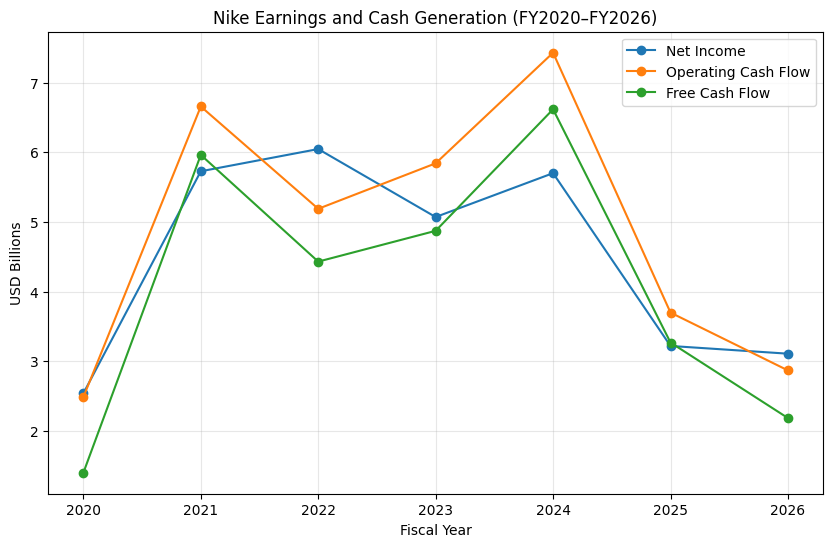

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    financials["Fiscal Year"],
    financials["Net Income ($bn)"],
    marker="o",
    label="Net Income"
)

plt.plot(
    financials["Fiscal Year"],
    financials["Operating Cash Flow ($bn)"],
    marker="o",
    label="Operating Cash Flow"
)

plt.plot(
    financials["Fiscal Year"],
    financials["Free Cash Flow ($bn)"],
    marker="o",
    label="Free Cash Flow"
)

plt.title("Nike Earnings and Cash Generation (FY2020–FY2026)")
plt.xlabel("Fiscal Year")
plt.ylabel("USD Billions")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

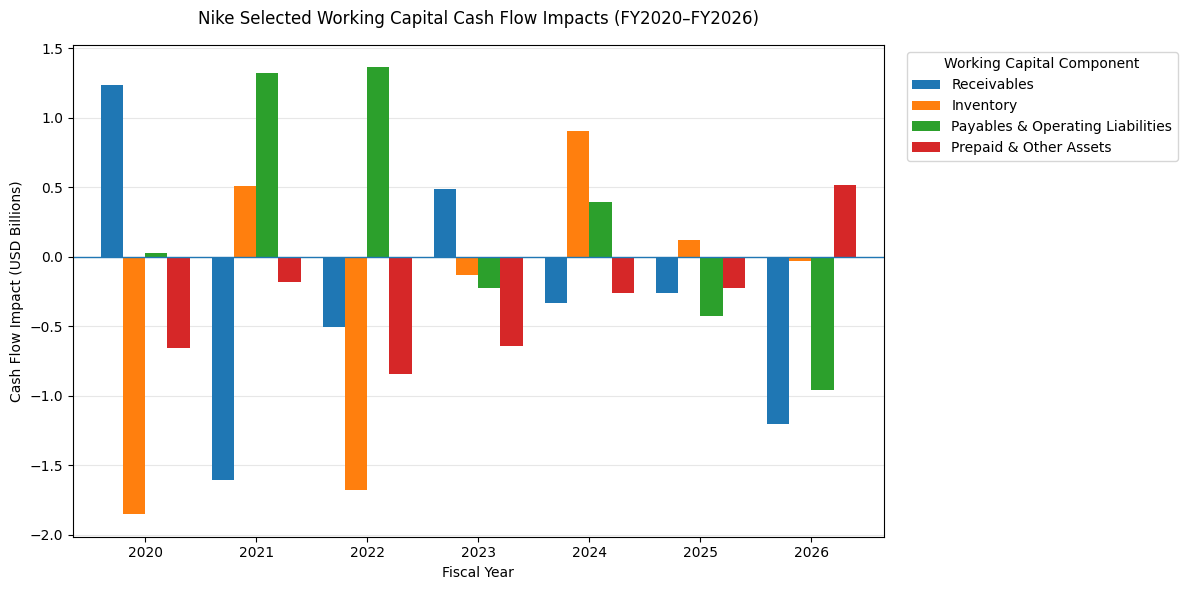

In [25]:
wc_plot = working_capital.set_index("Fiscal Year")[[
    "Receivables Cash Flow Impact ($bn)",
    "Inventory Cash Flow Impact ($bn)",
    "Payables & Operating Liabilities Cash Flow Impact ($bn)",
    "Prepaid & Other Assets Cash Flow Impact ($bn)"
]].copy()

wc_plot.columns = [
    "Receivables",
    "Inventory",
    "Payables & Operating Liabilities",
    "Prepaid & Other Assets"
]

ax = wc_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.axhline(0, linewidth=1)

ax.set_title(
    "Nike Selected Working Capital Cash Flow Impacts (FY2020–FY2026)",
    pad=15
)
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Cash Flow Impact (USD Billions)")

ax.legend(
    title="Working Capital Component",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Financial Position and Returns

This section evaluates Nike's balance-sheet strength, liquidity and leverage, followed by its ability to generate returns from its asset and equity base.

In [26]:
def get_annual_balance_metric(concept, column_name, start_year=2020, end_year=2026):
    data = pd.DataFrame(
        gaap_facts[concept]["units"]["USD"]
    )

    annual = data[
        (data["form"]=="10-K") &
        (data["fp"]=="FY")
    ].copy()

    annual["end"] = pd.to_datetime(annual["end"])

    annual = (
        annual
        .sort_values("filed")
        .drop_duplicates(subset="end", keep="last")
        .sort_values("end")
    )

    annual["Fiscal Year"]= annual["end"].dt.year

    annual = annual [
        annual["Fiscal Year"].between(start_year, end_year)
    ][["Fiscal Year", "val"]].copy()

    annual[column_name] = annual["val"] / 1e9

    return annual[
        ["Fiscal Year", column_name]
    ].reset_index(drop=True)


In [27]:
cash = get_annual_balance_metric(
    "CashAndCashEquivalentsAtCarryingValue",
    "Cash ($bn)"
)

assets = get_annual_balance_metric(
    "Assets",
    "Total Assets ($bn)"
)

equity = get_annual_balance_metric(
    "StockholdersEquity",
    "Shareholders' Equity ($bn)"
)

print(cash)
print()
print(assets)
print()
print(equity)

   Fiscal Year  Cash ($bn)
0         2020       8.348
1         2021       9.889
2         2022       8.574
3         2023       7.441
4         2024       9.860
5         2025       7.464
6         2026       7.563

   Fiscal Year  Total Assets ($bn)
0         2020              31.342
1         2021              37.740
2         2022              40.321
3         2023              37.531
4         2024              38.110
5         2025              36.579
6         2026              38.410

   Fiscal Year  Shareholders' Equity ($bn)
0         2020                       8.055
1         2021                      12.767
2         2022                      15.281
3         2023                      14.004
4         2024                      14.430
5         2025                      13.213
6         2026                      14.865


In [28]:
current_assets = get_annual_balance_metric(
    "AssetsCurrent",
    "Current Assets ($bn)"
)

current_liabilities = get_annual_balance_metric(
    "LiabilitiesCurrent",
    "Current Liabilities ($bn)"
)

debt_current = get_annual_balance_metric(
    "LongTermDebtCurrent",
    "Current Debt ($bn)"
)

debt_noncurrent = get_annual_balance_metric(
    "LongTermDebtNoncurrent",
    "Noncurrent Debt ($bn)"
)

print(current_assets)
print()
print(current_liabilities)
print()
print(debt_current)
print()
print(debt_noncurrent)

   Fiscal Year  Current Assets ($bn)
0         2020                20.556
1         2021                26.291
2         2022                28.213
3         2023                25.202
4         2024                25.382
5         2025                23.362
6         2026                24.603

   Fiscal Year  Current Liabilities ($bn)
0         2020                      8.284
1         2021                      9.674
2         2022                     10.730
3         2023                      9.256
4         2024                     10.593
5         2025                     10.566
6         2026                     12.547

   Fiscal Year  Current Debt ($bn)
0         2020               0.003
1         2021               0.000
2         2022               0.500
3         2023               0.000
4         2024               1.000
5         2025               0.000
6         2026               2.000

   Fiscal Year  Noncurrent Debt ($bn)
0         2020                  9.406
1        

In [29]:
short_term_borrowings = get_annual_balance_metric(
    "ShortTermBorrowings",
    "Short-Term Borrowings ($bn)"
)

print(short_term_borrowings)

   Fiscal Year  Short-Term Borrowings ($bn)
0         2020                        0.248
1         2021                        0.002
2         2022                        0.010
3         2023                        0.006
4         2024                        0.006
5         2025                        0.005


**Data note:** The SEC standardized `ShortTermBorrowings` concept does not provide a FY2026 observation for Nike. Nike's FY2026 annual filing reports Notes Payable of $0, so FY2026 short-term borrowings are manually set to $0.0bn for consistency in the borrowing calculation.

In [30]:
short_term_borrowings = pd.concat([
    short_term_borrowings,
    pd.DataFrame({
        "Fiscal Year": [2026],
        "Short-Term Borrowings ($bn)": [0.0]
    })
], ignore_index=True)

short_term_borrowings

,Fiscal Year,Short-Term Borrowings ($bn)
0,2020,0.248
1,2021,0.002
2,2022,0.010
3,2023,0.006
4,2024,0.006
5,2025,0.005
6,2026,0.000


In [31]:
balance_sheet = (
    cash
    .merge(assets, on="Fiscal Year", how="outer")
    .merge(equity, on="Fiscal Year", how="outer")
    .merge(current_assets, on="Fiscal Year", how="outer")
    .merge(current_liabilities, on="Fiscal Year", how="outer")
    .merge(debt_current, on="Fiscal Year", how="outer")
    .merge(debt_noncurrent, on="Fiscal Year", how="outer")
    .merge(short_term_borrowings, on="Fiscal Year", how="outer")
    .sort_values("Fiscal Year")
    .reset_index(drop=True)   
)

balance_sheet

,Fiscal Year,Cash ($bn),Total Assets ($bn),Shareholders' Equity ($bn),Current Assets ($bn),Current Liabilities ($bn),Current Debt ($bn),Noncurrent Debt ($bn),Short-Term Borrowings ($bn)
0,2020,8.348,31.342,8.055,20.556,8.284,0.003,9.406,0.248
1,2021,9.889,37.740,12.767,26.291,9.674,0.000,9.413,0.002
2,2022,8.574,40.321,15.281,28.213,10.730,0.500,8.920,0.010
3,2023,7.441,37.531,14.004,25.202,9.256,0.000,8.927,0.006
4,2024,9.860,38.110,14.430,25.382,10.593,1.000,7.903,0.006
5,2025,7.464,36.579,13.213,23.362,10.566,0.000,7.961,0.005
6,2026,7.563,38.410,14.865,24.603,12.547,2.000,5.942,0.000


In [32]:
balance_sheet["Interest-Bearing Borrowings ($bn)"] = (
    balance_sheet["Current Debt ($bn)"]
    + balance_sheet["Noncurrent Debt ($bn)"]
    + balance_sheet["Short-Term Borrowings ($bn)"]
)

balance_sheet["Current Ratio"] =(
    balance_sheet["Current Assets ($bn)"]
    / balance_sheet["Current Liabilities ($bn)"]
)

balance_sheet["Borrowings-to-Equity"] = (
    balance_sheet["Interest-Bearing Borrowings ($bn)"]
    / balance_sheet["Shareholders\' Equity ($bn)"]
)

balance_sheet["Net Borrowings ($bn)"] =(
    balance_sheet["Interest-Bearing Borrowings ($bn)"]
    - balance_sheet["Cash ($bn)"]
)

balance_sheet[
    ["Interest-Bearing Borrowings ($bn)", "Current Ratio", "Borrowings-to-Equity", "Net Borrowings ($bn)"]
] = balance_sheet [
    ["Interest-Bearing Borrowings ($bn)", "Current Ratio", "Borrowings-to-Equity", "Net Borrowings ($bn)"]
].round(2)

balance_sheet[[
    "Fiscal Year",
    "Cash ($bn)",
    "Interest-Bearing Borrowings ($bn)",
    "Net Borrowings ($bn)",
    "Current Ratio",
    "Borrowings-to-Equity"
]]

,Fiscal Year,Cash ($bn),Interest-Bearing Borrowings ($bn),Net Borrowings ($bn),Current Ratio,Borrowings-to-Equity
0,2020,8.348,9.66,1.31,2.48,1.20
1,2021,9.889,9.42,-0.47,2.72,0.74
2,2022,8.574,9.43,0.86,2.63,0.62
3,2023,7.441,8.93,1.49,2.72,0.64
4,2024,9.860,8.91,-0.95,2.40,0.62
5,2025,7.464,7.97,0.50,2.21,0.60
6,2026,7.563,7.94,0.38,1.96,0.53


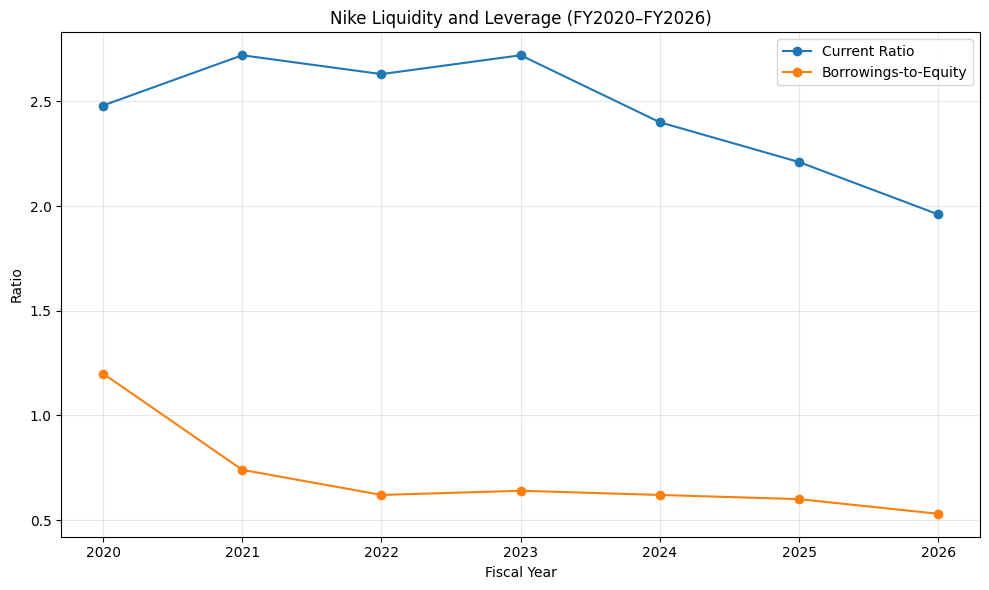

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    balance_sheet["Fiscal Year"],
    balance_sheet["Current Ratio"],
    marker="o",
    label="Current Ratio"
)

plt.plot(
    balance_sheet["Fiscal Year"],
    balance_sheet["Borrowings-to-Equity"],
    marker="o",
    label="Borrowings-to-Equity"
)

plt.title("Nike Liquidity and Leverage (FY2020–FY2026)")
plt.xlabel("Fiscal Year")
plt.ylabel("Ratio")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Return on Assets and Return on Equity

ROA and ROE are calculated using average total assets and average shareholders' equity to better match each year's net income with the capital base used to generate it.

In [34]:
returns = financials[
    ["Fiscal Year", "Net Income ($bn)"]
].merge(
    balance_sheet[
        ["Fiscal Year", "Total Assets ($bn)", "Shareholders' Equity ($bn)"]
    ],
    on="Fiscal Year",
    how="inner"
)

returns

,Fiscal Year,Net Income ($bn),Total Assets ($bn),Shareholders' Equity ($bn)
0,2020,2.539,31.342,8.055
1,2021,5.727,37.740,12.767
2,2022,6.046,40.321,15.281
3,2023,5.070,37.531,14.004
4,2024,5.700,38.110,14.430
5,2025,3.219,36.579,13.213
6,2026,3.108,38.410,14.865


In [35]:
returns["Average Assets ($bn)"] = (
    returns["Total Assets ($bn)"]
    + returns["Total Assets ($bn)"].shift(1)
) / 2

returns["Average Equity ($bn)"] = (
    returns["Shareholders\' Equity ($bn)"]
    + returns["Shareholders\' Equity ($bn)"].shift(1)
) / 2 

returns["ROA (%)"] = (
    returns["Net Income ($bn)"]
    / returns["Average Assets ($bn)"]
    *100
)

returns["ROE (%)"] = (
    returns["Net Income ($bn)"]
    / returns["Average Equity ($bn)"]
    *100
)

returns[[
    "Fiscal Year",
    "Net Income ($bn)",
    "Average Assets ($bn)",
    "Average Equity ($bn)",
    "ROA (%)",
    "ROE (%)"
]].round(2)

,Fiscal Year,Net Income ($bn),Average Assets ($bn),Average Equity ($bn),ROA (%),ROE (%)
0,2020,2.54,NaN,NaN,NaN,NaN
1,2021,5.73,34.54,10.41,16.58,55.01
2,2022,6.05,39.03,14.02,15.49,43.11
3,2023,5.07,38.93,14.64,13.02,34.63
4,2024,5.70,37.82,14.22,15.07,40.09
5,2025,3.22,37.34,13.82,8.62,23.29
6,2026,3.11,37.49,14.04,8.29,22.14


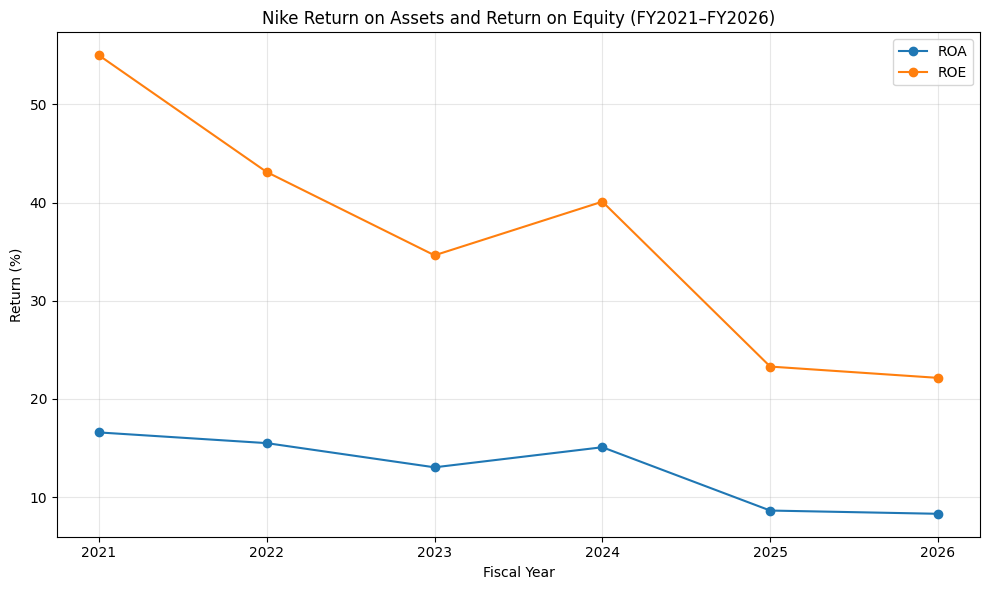

In [36]:
returns_plot = returns.dropna(subset=["ROA (%)", "ROE (%)"])

plt.figure(figsize=(10, 6))

plt.plot(
    returns_plot["Fiscal Year"],
    returns_plot["ROA (%)"],
    marker="o",
    label="ROA"
)

plt.plot(
    returns_plot["Fiscal Year"],
    returns_plot["ROE (%)"],
    marker="o",
    label="ROE"
)

plt.title("Nike Return on Assets and Return on Equity (FY2021–FY2026)")
plt.xlabel("Fiscal Year")
plt.ylabel("Return (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [37]:
historical_scenarios_stats =  financials.loc[
    financials["Fiscal Year"].between(2021,2026),
    ["Fiscal Year","Revenue Growth (%)", "EBIT Margin (%)"]
].copy()

historical_scenarios_stats

,Fiscal Year,Revenue Growth (%),EBIT Margin (%)
1,2021,19.08,15.54
2,2022,4.88,14.68
3,2023,9.65,12.10
4,2024,0.28,12.73
5,2025,-9.84,8.16
6,2026,0.19,8.30


In [38]:
historical_scenarios_stats[
    ["Revenue Growth (%)", "EBIT Margin (%)"]
].describe().round(2)

,Revenue Growth (%),EBIT Margin (%)
count,6.00,6.00
mean,4.04,11.92
std,9.80,3.12
min,-9.84,8.16
25%,0.21,9.25
50%,2.58,12.42
75%,8.46,14.19
max,19.08,15.54


## 4. FY2027 Scenario Analysis

To assess potential FY2027 operating outcomes, three illustrative scenarios are constructed using revenue growth and EBIT margin as the primary drivers.

The assumptions are informed by Nike's FY2021–FY2026 historical performance and recent operating trajectory. Historical revenue growth had a median of 2.58%, while EBIT margin averaged 11.92%. However, EBIT margin declined to 8.16% in FY2025 and remained at 8.30% in FY2026.

Therefore:

- **Bear:** assumes renewed revenue contraction and further margin pressure.
- **Base:** assumes moderate revenue growth near the historical median and a modest recovery in operating margin.
- **Bull:** assumes stronger revenue growth and margin recovery, while remaining below Nike's historical average EBIT margin.

These scenarios are illustrative analytical assumptions and do not represent Nike management guidance or market consensus forecasts.

In [39]:
scenarios = pd.DataFrame({
    "Scenario": ["Bear", "Base", "Bull"],
    "Revenue Growth (%)": [-3.0,3.0,7.0],
    "EBIT Margin (%)": [7.5,9.0,10.5]
})
scenarios

,Scenario,Revenue Growth (%),EBIT Margin (%)
0,Bear,-3.0,7.5
1,Base,3.0,9.0
2,Bull,7.0,10.5


In [40]:
revenue2026 = financials.loc[
    financials["Fiscal Year"] == 2026,
    "Revenue ($bn)"
].iloc[0]

revenue2026

np.float64(46.398)

In [41]:
scenarios["FY2027 Revenue ($bn)"] = (
    revenue2026 *
    (1 + scenarios["Revenue Growth (%)"]/100)
)

scenarios["FY2027 EBIT ($bn)"] = (
    scenarios["FY2027 Revenue ($bn)"] *
    scenarios["EBIT Margin (%)"] / 100
)

scenarios = scenarios.round(2)

scenarios

,Scenario,Revenue Growth (%),EBIT Margin (%),FY2027 Revenue ($bn),FY2027 EBIT ($bn)
0,Bear,-3.0,7.5,45.01,3.38
1,Base,3.0,9.0,47.79,4.30
2,Bull,7.0,10.5,49.65,5.21


In [42]:
scenario_ebit = pd.DataFrame({
    "Case": ["FY2026 Actual", "FY2027 Bear", "FY2027 Base", "FY2027 Bull"],
    "EBIT ($bn)": [
        financials.loc[
            financials["Fiscal Year"] == 2026,
            "EBIT ($bn)"
        ].iloc[0],
        scenarios.loc[scenarios["Scenario"] == "Bear", "FY2027 EBIT ($bn)"].iloc[0],
        scenarios.loc[scenarios["Scenario"] == "Base", "FY2027 EBIT ($bn)"].iloc[0],
        scenarios.loc[scenarios["Scenario"] == "Bull", "FY2027 EBIT ($bn)"].iloc[0]
    ]
})

scenario_ebit

,Case,EBIT ($bn)
0,FY2026 Actual,3.85
1,FY2027 Bear,3.38
2,FY2027 Base,4.30
3,FY2027 Bull,5.21


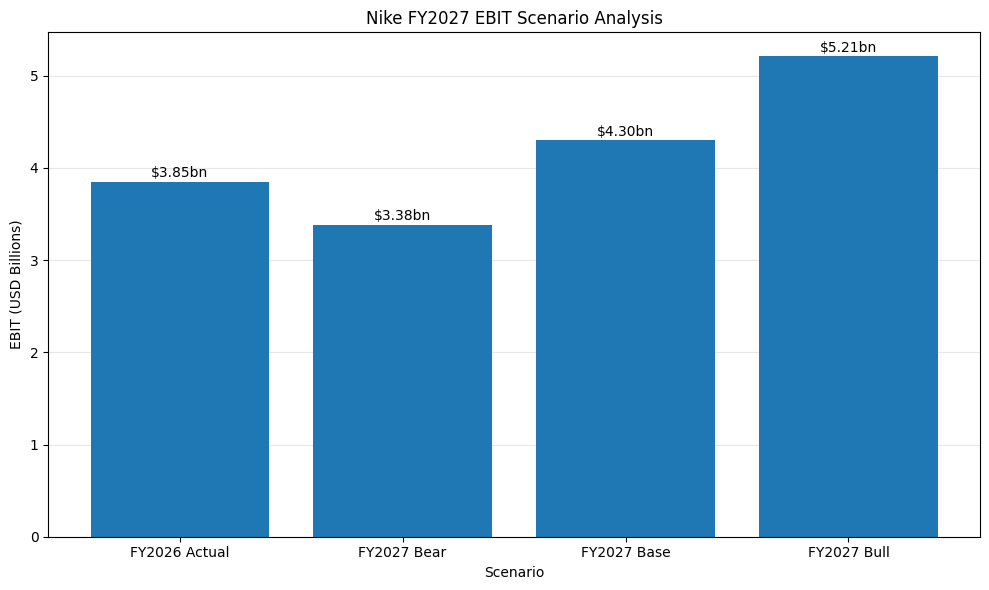

In [43]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    scenario_ebit["Case"],
    scenario_ebit["EBIT ($bn)"]
)

plt.title("Nike FY2027 EBIT Scenario Analysis")
plt.xlabel("Scenario")
plt.ylabel("EBIT (USD Billions)")

plt.grid(axis="y", alpha=0.3)
plt.gca().set_axisbelow(True)

# Add EBIT values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"${height:.2f}bn",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 5. Final Conclusions

Nike's financial performance shows a clear shift from strong profitability and cash generation earlier in the period toward weaker operating performance in FY2025–FY2026.

### Key Findings

- **Revenue and profitability:** Revenue declined by 9.84% in FY2025 before stabilising in FY2026. EBIT margin fell from 12.73% in FY2024 to 8.16% in FY2025 and recovered only slightly to 8.30% in FY2026.

- **Cost structure:** The profitability decline was driven by both weaker gross margins and a higher SG&A burden relative to revenue. This caused EBIT to decline substantially faster than revenue in FY2025.

- **Cash generation:** Free cash flow declined from \$6.62bn in FY2024 to \$2.18bn in FY2026. FY2026 operating cash flow was additionally pressured by unfavourable working-capital movements, particularly receivables and payables/other operating liabilities.

- **Financial position:** Despite weaker operating performance, leverage remained relatively controlled. Interest-bearing borrowings declined from \$9.66bn in FY2020 to \$7.94bn in FY2026, while Borrowings-to-Equity fell from 1.20 to 0.53. However, the Current Ratio declined to 1.96, indicating weaker short-term liquidity compared with previous years. The borrowing measure used here includes short-term borrowings and current and noncurrent long-term debt, but excludes operating lease liabilities.

- **Returns:** ROA declined from 16.58% in FY2021 to 8.29% in FY2026, while ROE declined from 55.01% to 22.14%, reflecting substantially weaker returns generated from Nike's asset and equity base.

- **FY2027 scenarios:** The scenario analysis produces EBIT outcomes ranging from \$3.38bn in the Bear case to \$5.21bn in the Bull case. The Base case produces $4.30bn of EBIT, showing that a combination of moderate revenue growth and margin recovery could generate a meaningful improvement from FY2026.

### Overall Assessment

The analysis suggests that Nike entered a period of significant operating pressure in FY2025 and showed signs of stabilisation rather than a full recovery in FY2026. Profitability, cash generation and returns remain well below earlier-period levels, while the balance sheet remains comparatively resilient due to lower leverage. Future operating improvement will depend not only on renewed revenue growth but also on Nike's ability to rebuild margins and improve cash conversion.